## 1. Load and Inspect the Email Dataset
This first cell finds the CEAS email CSV in either the local workspace or the Kaggle input mount, prints the raw schema, and records the initial label distribution and sample rows before feature engineering.

In [40]:
# Config cell: locate CEAS_08.csv in either a local workspace or Kaggle environment
from pathlib import Path
import pandas as pd

pd.set_option('display.max_colwidth', 60)
pd.set_option('display.width', 120)
search_roots = [Path.cwd()]
if Path('/kaggle/input').exists():
    search_roots.append(Path('/kaggle/input'))

candidates = []
for root in search_roots:
    candidates.extend(root.glob('**/CEAS_08.csv'))

if not candidates:
    raise FileNotFoundError(
        "CEAS_08.csv not found. If on Kaggle, confirm the dataset is added via ' + Add Input' in the right sidebar, then re-run the /kaggle/input walk."
    )

data_path = candidates[0]
print(f'Using dataset path: {data_path}')

df = pd.read_csv(data_path)
print(f'Raw shape: {df.shape}')

print('\nDtypes:')
print(df.dtypes)

print('\nNull counts:')
print(df.isna().sum())

print('\nLabel balance (original labels):')
label_counts = df['label'].value_counts(dropna=False)
label_percent = df['label'].value_counts(normalize=True, dropna=False).mul(100).round(2)
print(pd.concat([label_counts, label_percent], axis=1, keys=['count', 'percentage']))

print('\nSample rows (5):')
sample_display = df[['sender', 'receiver', 'date', 'subject', 'body', 'urls']].head(5).copy()
for col in ['subject', 'body']:
    sample_display[col] = sample_display[col].astype(str).str.slice(0, 50) + '...'
print(sample_display.to_string(index=False))

# Drop rows where the target or sender are missing; these values are not recoverable
df = df.dropna(subset=['label', 'sender']).copy()

print('\nRows after dropping unrecoverable nulls:', df.shape[0])
print('\nNull counts after cleanup:')
print(df.isna().sum())

Using dataset path: /kaggle/input/datasets/naserabdullahalam/phishing-email-dataset/CEAS_08.csv
Raw shape: (39154, 7)

Dtypes:
sender      object
receiver    object
date        object
subject     object
body        object
label        int64
urls         int64
dtype: object

Null counts:
sender        0
receiver    462
date          0
subject      28
body          0
label         0
urls          0
dtype: int64

Label balance (original labels):
       count  percentage
label                   
1      21842       55.78
0      17312       44.22

Sample rows (5):
                                                sender                                       receiver                            date                                               subject                                                    body  urls
                      Young Esposito <Young@iworld.de>                    user4@gvc.ceas-challenge.cc Tue, 05 Aug 2008 16:31:02 -0700                          Never agree to be a loser.

## 2. Engineer Email-Only Features
The next block turns the raw sender, receiver, date, subject, body, and URL fields into a small engineered feature matrix that is better suited for XGBoost.

In [41]:
import re
from datetime import datetime

freemail_providers = {'gmail.com', 'yahoo.com', 'outlook.com', 'hotmail.com', 'aol.com'}
urgency_keywords = [
    'urgent', 'verify', 'suspended', 'action required', 'password', 'confirm',
    'immediately', 'click here', 'account'
]

# Helper functions

def safe_domain(addr):
    if pd.isna(addr):
        return None
    addr = str(addr).strip()
    if '@' not in addr:
        return None
    return addr.split('@')[-1].lower()


def count_keywords(text, keywords):
    if pd.isna(text):
        return 0
    text = str(text).lower()
    count = 0
    for kw in keywords:
        if kw in text:
            count += 1
    return count


def caps_ratio(text):
    if pd.isna(text) or str(text) == '':
        return 0.0
    text = str(text)
    alpha = sum(ch.isalpha() for ch in text)
    if alpha == 0:
        return 0.0
    return sum(ch.isupper() for ch in text if ch.isalpha()) / alpha


def parse_datetime_safe(date_val):
    if pd.isna(date_val):
        return pd.NaT
    try:
        dt = pd.to_datetime(date_val, utc=False, errors='coerce')
        if pd.isna(dt):
            return pd.NaT
        return dt
    except Exception:
        return pd.NaT


# Build engineered features
sender_domain = df['sender'].apply(safe_domain)
sender_is_freemail = sender_domain.apply(lambda x: int(x in freemail_providers) if x is not None else 0)
sender_domain_length = sender_domain.apply(lambda x: len(x) if x is not None else 0)
receiver_domain = df['receiver'].apply(safe_domain)
domain_mismatch = ((sender_domain != receiver_domain) & sender_domain.notna() & receiver_domain.notna()).astype(int)

# Normalize the raw date column row-by-row to avoid mixed-timezone parsing issues.
parsed_dates = df['date'].apply(parse_datetime_safe)
parsed_dates = pd.to_datetime(parsed_dates, errors='coerce')

# Extract hour and weekend features only after the date series is guaranteed datetime-like.
email_hour = parsed_dates.dt.hour
email_hour = email_hour.fillna(email_hour.median())
is_weekend = parsed_dates.dt.dayofweek.isin([5, 6]).astype(int)

subject = df['subject'].fillna('')
subject_length = subject.astype(str).str.len()
subject_urgency_count = subject.apply(lambda x: count_keywords(x, urgency_keywords))
subject_exclamation_count = subject.astype(str).str.count('!')
subject_caps_ratio = subject.apply(caps_ratio)

body = df['body'].fillna('')
body_length = body.astype(str).str.len()
body_urgency_count = body.apply(lambda x: count_keywords(x, urgency_keywords))
body_html_tag_count = body.astype(str).str.count(r'<[^>]+>')
body_link_count = body.astype(str).str.count(r'http|www')
body_exclamation_count = body.astype(str).str.count('!')
body_caps_ratio = body.apply(caps_ratio)

urls_present = df['urls'].fillna(0).astype(int)

engineered_df = pd.DataFrame({
    'label': df['label'],
    'sender_is_freemail': sender_is_freemail,
    'sender_domain_length': sender_domain_length,
    'domain_mismatch': domain_mismatch,
    'email_hour': email_hour.astype(float),
    'is_weekend': is_weekend,
    'subject_length': subject_length.astype(float),
    'subject_urgency_count': subject_urgency_count.astype(float),
    'subject_exclamation_count': subject_exclamation_count.astype(float),
    'subject_caps_ratio': subject_caps_ratio.astype(float),
    'body_length': body_length.astype(float),
    'body_urgency_count': body_urgency_count.astype(float),
    'body_html_tag_count': body_html_tag_count.astype(float),
    'body_link_count': body_link_count.astype(float),
    'body_exclamation_count': body_exclamation_count.astype(float),
    'body_caps_ratio': body_caps_ratio.astype(float),
    'urls_present': urls_present,
})

print('Final engineered feature list and shape:')
print(engineered_df.shape)
print(engineered_df.dtypes)
print('\nFeature columns:', list(engineered_df.columns.drop('label')))


Final engineered feature list and shape:
(39154, 17)
label                          int64
sender_is_freemail             int64
sender_domain_length           int64
domain_mismatch                int64
email_hour                   float64
is_weekend                     int64
subject_length               float64
subject_urgency_count        float64
subject_exclamation_count    float64
subject_caps_ratio           float64
body_length                  float64
body_urgency_count           float64
body_html_tag_count          float64
body_link_count              float64
body_exclamation_count       float64
body_caps_ratio              float64
urls_present                   int64
dtype: object

Feature columns: ['sender_is_freemail', 'sender_domain_length', 'domain_mismatch', 'email_hour', 'is_weekend', 'subject_length', 'subject_urgency_count', 'subject_exclamation_count', 'subject_caps_ratio', 'body_length', 'body_urgency_count', 'body_html_tag_count', 'body_link_count', 'body_exclamation_c

## 3. Confirm Labels and Create the Train/Test Split
This section validates the expected phishing label convention, checks the engineered feature matrix for missing or infinite values, and then performs the stratified 80/20 split.

In [42]:
from sklearn.model_selection import train_test_split
import numpy as np

# Confirm label convention from the actual dataset before remapping.
label_counts = df['label'].value_counts(dropna=False)
print('Original label counts before remap:')
print(label_counts)

# Map to 0/1 only if required; keep the actual dataset convention explicit.
if set(label_counts.index.astype(str)) == {'0', '1'}:
    y = df['label'].astype(int)
elif set(label_counts.index.astype(str)) == {'-1', '1'}:
    # In this dataset, -1 is typically phishing and 1 is legitimate; map accordingly.
    mapping = {-1: 1, 1: 0}
    df['label'] = df['label'].map(mapping)
    y = df['label'].astype(int)
else:
    raise ValueError(f'Unexpected label values found: {label_counts.index.tolist()}')

# Confirm the engineered matrix is clean.
X = engineered_df.drop(columns=['label'])
missing_counts = X.isna().sum()
inf_mask = np.isinf(X.select_dtypes(include=[np.number])).sum()
print('\nMissing values in engineered features:')
print(missing_counts)
print('\nInfinite values in engineered features:')
print(inf_mask)

if X.isna().sum().sum() != 0 or np.isinf(X.select_dtypes(include=[np.number])).sum().sum() != 0:
    raise ValueError('Missing or infinite values remain in the engineered feature set.')

# Separate features and target.
y = df['label'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print('\nTrain set shape:', X_train.shape, y_train.shape)
print('Test set shape:', X_test.shape, y_test.shape)

for name, y_split in [('Train', y_train), ('Test', y_test)]:
    counts = y_split.value_counts().sort_index()
    percentages = y_split.value_counts(normalize=True).sort_index().mul(100).round(2)
    print(f'\n{name} class balance:')
    print(pd.concat([counts, percentages], axis=1, keys=['count', 'percentage']))


Original label counts before remap:
label
1    21842
0    17312
Name: count, dtype: int64

Missing values in engineered features:
sender_is_freemail           0
sender_domain_length         0
domain_mismatch              0
email_hour                   0
is_weekend                   0
subject_length               0
subject_urgency_count        0
subject_exclamation_count    0
subject_caps_ratio           0
body_length                  0
body_urgency_count           0
body_html_tag_count          0
body_link_count              0
body_exclamation_count       0
body_caps_ratio              0
urls_present                 0
dtype: int64

Infinite values in engineered features:
sender_is_freemail           0
sender_domain_length         0
domain_mismatch              0
email_hour                   0
is_weekend                   0
subject_length               0
subject_urgency_count        0
subject_exclamation_count    0
subject_caps_ratio           0
body_length                  0
body_urgen

## 4. Fit the Baseline XGBoost Model
We train a compact XGBoost classifier on the engineered email features and use the training accuracy as a quick sanity check that the model is learning correctly.

In [43]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='logloss',
    random_state=42,
)

model.fit(X_train, y_train)

train_pred = model.predict(X_train)
train_accuracy = accuracy_score(y_train, train_pred)

print('Training accuracy:', round(train_accuracy, 4))

Training accuracy: 0.9911


## 5. Derive Gain-Based Feature Importance
This block extracts the XGBoost gain importance values and prints the top-ranked features so we can compare them directly with the SHAP explanation later in the notebook.

In [44]:
from pathlib import Path
import pandas as pd

output_dir = Path('/kaggle/working') if Path('/kaggle/working').exists() else Path.cwd() / 'outputs'
output_dir.mkdir(parents=True, exist_ok=True)

feature_gain = model.get_booster().get_score(importance_type='gain')
importance_df = pd.DataFrame({
    'feature_name': list(feature_gain.keys()),
    'importance_score': list(feature_gain.values()),
}).sort_values('importance_score', ascending=False).reset_index(drop=True)

print('Feature importance table (gain-based):')
print(importance_df.head(10).to_string(index=False))

print('\nTop 7 features for chapter 4:')
print(importance_df.head(7).round({'importance_score': 6}).to_string(index=False))

Feature importance table (gain-based):
             feature_name  importance_score
              body_length         54.348064
      body_html_tag_count         53.646465
          body_caps_ratio         27.596704
             urls_present         24.533352
       body_urgency_count         21.553209
          body_link_count         20.940956
   body_exclamation_count         20.255928
    subject_urgency_count         12.717711
subject_exclamation_count         11.167539
          domain_mismatch          8.794921

Top 7 features for chapter 4:
          feature_name  importance_score
           body_length         54.348064
   body_html_tag_count         53.646465
       body_caps_ratio         27.596704
          urls_present         24.533352
    body_urgency_count         21.553209
       body_link_count         20.940956
body_exclamation_count         20.255928


## 6. Visualize the Top Gain Features
This visual shows the ranking produced by XGBoost’s gain importance measure so the audience can quickly scan the most influential engineered email signals.

/tmp/ipykernel_58/1081997331.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


Saved plot to: /kaggle/working/email_feature_importance_all.png


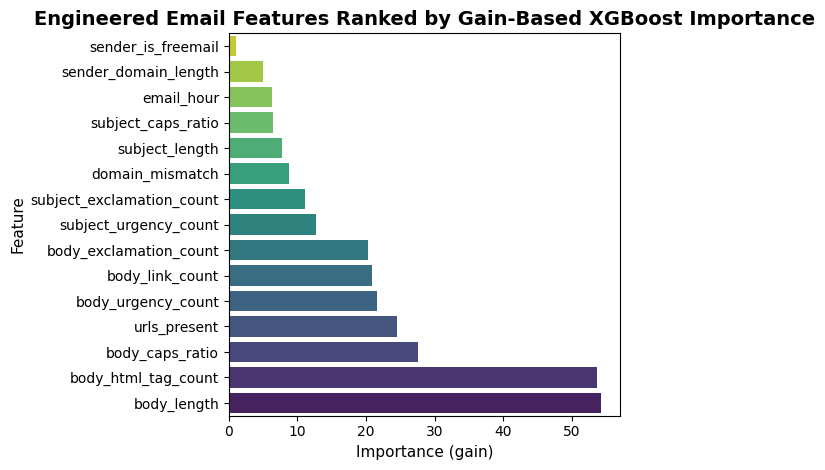

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

ax = sns.barplot(
    data=importance_df,
    x='importance_score',
    y='feature_name',
    palette='viridis',
    orient='h',
)
ax.set_title('Engineered Email Features Ranked by Gain-Based XGBoost Importance', fontsize=14, weight='bold')
ax.set_xlabel('Importance (gain)', fontsize=11)
ax.set_ylabel('Feature', fontsize=11)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(output_dir / 'email_feature_importance_all.png', dpi=300, bbox_inches='tight')
print('Saved plot to:', output_dir / 'email_feature_importance_all.png')
plt.show()

## 7. SHAP TreeExplainer Interpretation
This section computes a SHAP value summary over the test set, ranks features by mean absolute SHAP impact, and saves the beeswarm plot for direct comparison with the gain-based ranking.

SHAP summary ranking (mean |SHAP value|):
             feature_name  shap_mean_abs_value
              body_length             2.623282
          body_caps_ratio             1.073825
          body_link_count             0.846297
           subject_length             0.749674
             urls_present             0.743019
   body_exclamation_count             0.704178
       subject_caps_ratio             0.564950
     sender_domain_length             0.451049
subject_exclamation_count             0.187730
      body_html_tag_count             0.185543
Saved SHAP beeswarm plot to: /kaggle/working/email_shap_summary_beeswarm.png


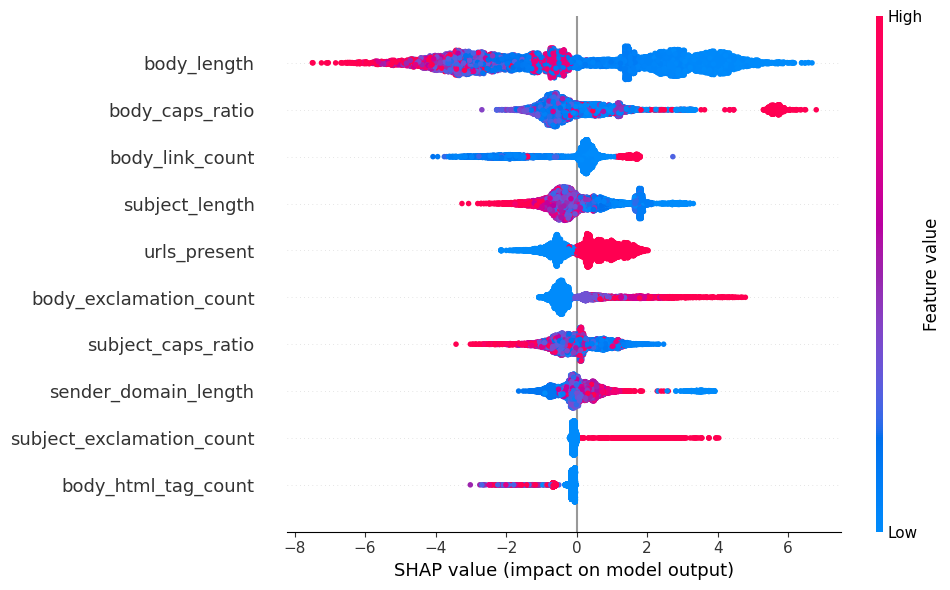


SHAP top-7 vs gain-based top-7 overlap: 5/7 features
Discrepancies noted: ['body_html_tag_count', 'body_urgency_count', 'subject_caps_ratio', 'subject_length']
These differences are worth flagging in the write-up as a ranking-consistency check.


In [46]:
import numpy as np
import shap
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
if isinstance(shap_values, list):
    shap_array = np.asarray(shap_values[1])
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_array = shap_values[:, :, 1]
else:
    shap_array = np.asarray(shap_values)
if shap_array.ndim != 2:
    raise ValueError(f'Unexpected SHAP value shape: {shap_array.shape}')
shap_importance = pd.Series(
    np.abs(shap_array).mean(axis=0),
    index=X_test.columns,
).sort_values(ascending=False)
shap_rank_df = shap_importance.reset_index()
shap_rank_df.columns = ['feature_name', 'shap_mean_abs_value']
shap_rank_df = shap_rank_df.sort_values('shap_mean_abs_value', ascending=False).reset_index(drop=True)
print('SHAP summary ranking (mean |SHAP value|):')
print(shap_rank_df.head(10).round({'shap_mean_abs_value': 6}).to_string(index=False))
shap.summary_plot(shap_array, X_test, max_display=10, show=False)
fig = plt.gcf()
fig.set_size_inches(10, 6)
plt.tight_layout()
fig.savefig(output_dir / 'email_shap_summary_beeswarm.png', dpi=300, bbox_inches='tight')
print('Saved SHAP beeswarm plot to:', output_dir / 'email_shap_summary_beeswarm.png')
plt.show()
plt.close(fig)
shap_top7 = shap_rank_df.head(7).set_index('feature_name')['shap_mean_abs_value']
gain_top7 = importance_df.head(7).set_index('feature_name')['importance_score']
shared_features = set(shap_top7.index).intersection(set(gain_top7.index))
print(f'\nSHAP top-7 vs gain-based top-7 overlap: {len(shared_features)}/7 features')
if len(shared_features) == 7:
    print('The SHAP top-7 ranking matches the gain-based top-7 ranking exactly.')
else:
    discrepancies = sorted(set(gain_top7.index).symmetric_difference(set(shap_top7.index)))
    print('Discrepancies noted:', discrepancies)
    print('These differences are worth flagging in the write-up as a ranking-consistency check.')

## 8. Compare SHAP and Gain Rankings
The last interpretation step compares the top-7 SHAP feature set against the top-7 gain set to identify overlap and potential ranking differences before exporting the final shortlist.

In [47]:
import json

selected_features = importance_df.head(7)['feature_name'].tolist()
selected_path = output_dir / 'email_selected_features_top7.txt'
with open(selected_path, 'w', encoding='utf-8') as f:
    f.write('\n'.join(selected_features))

json_path = output_dir / 'email_selected_features_top7.json'
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(selected_features, f, indent=2)

importance_df.to_csv(output_dir / 'email_feature_importance_ranked.csv', index=False)

print('Saved selected feature subset to:', selected_path)
print('Saved selected feature subset JSON to:', json_path)
print('Saved ranked importance table to:', output_dir / 'email_feature_importance_ranked.csv')
print('Saved plots already exist in:', output_dir)

Saved selected feature subset to: /kaggle/working/email_selected_features_top7.txt
Saved selected feature subset JSON to: /kaggle/working/email_selected_features_top7.json
Saved ranked importance table to: /kaggle/working/email_feature_importance_ranked.csv
Saved plots already exist in: /kaggle/working


## 9. Export the Final Ranked Feature List
This export step writes the selected top-7 features to both text and JSON files and saves the entire gain-ranked importance table for reuse outside the notebook.